# Cellpose 3D vs Planar-Stitched Segmentation Comparison

This notebook compares two approaches for volumetric cell segmentation:
1. **True 3D**: Cellpose runs on all three orthogonal views (XY, ZY, ZX) and combines them
2. **Planar-Stitched**: Cellpose runs 2D on each Z-slice, then stitches masks across Z

We compare:
- Number of cells detected
- Mask overlap/consistency
- Runtime performance
- Visual comparison of segmentation results

In [1]:
!uv pip install ../../../mbo_utilities

Using Python 3.12.9 environment at: C:\Users\RBO\repos\LBM-Suite2p-Python\.venv
Resolved 153 packages in 309ms
   Building mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
      Built mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
Prepared 1 package in 1.01s
Uninstalled 1 package in 7ms
Installed 1 package in 15ms
 ~ mbo-utilities==2.3.0 (from file:///C:/Users/RBO/repos/mbo_utilities)


In [2]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tifffile
from tqdm.auto import tqdm

from mbo_utilities import imread, imwrite
from cellpose import models, core, io, plot

io.logger_setup()

print(f"GPU available: {core.use_gpu()}")

2025-12-03 14:17:15,344 [INFO] WRITING LOG OUTPUT TO C:\Users\RBO\.cellpose\run.log
2025-12-03 14:17:15,344 [INFO] 
cellpose version: 	4.0.7 
platform:       	win32 
python version: 	3.12.9 
torch version:  	2.9.1+cu126
2025-12-03 14:17:15,402 [INFO] ** TORCH CUDA version installed and working. **
GPU available: True


## Configuration

In [3]:
# Input path - change this to your data location
INPUT_PATH = Path(r"D:\raw_scanimage_tiffs")

# Output directory
OUTPUT_DIR = INPUT_PATH / "cellpose_comparison"
OUTPUT_DIR.mkdir(exist_ok=True)

# Cellpose parameters
FLOW_THRESHOLD = 0.4
CELLPROB_THRESHOLD = 0.0
STITCH_THRESHOLD = 0.5  # For planar-stitched mode

# Anisotropy: ratio of Z-step to XY pixel size (from your microscope)
# e.g., if Z-step = 15µm and XY pixel = 1.5µm, anisotropy = 10
# Set to None to let Cellpose auto-detect (or 1.0 for isotropic)
ANISOTROPY = None  # Set based on your actual voxel sizes!

# Force recompute even if results exist
FORCE = True  # Set True to re-run with corrected parameters

## Load Data

In [4]:
# Check for existing zarr or load raw data
zarr_path = OUTPUT_DIR / "volume.zarr"

if zarr_path.exists() and not FORCE:
    print(f"Loading existing zarr from {zarr_path}")
    volume = imread(zarr_path)
else:
    print(f"Loading raw data from {INPUT_PATH}")
    volume = imread(INPUT_PATH)
    print(f"Raw data shape: {volume.shape}")

    # Save to zarr for faster future loading
    print("Saving to zarr...")
    imwrite(volume, zarr_path, ext=".zarr", overwrite=True)

print(f"Volume shape: {volume.shape}")

Loading raw data from D:\raw_scanimage_tiffs


Counting frames:   0%|          | 0/6 [00:00<?, ?it/s]

Raw data shape: (1163, 14, 448, 448)
Saving to zarr...


Saving plane01_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane02_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

...

Saving plane11_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane12_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane13_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane14_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Volume shape: (1163, 14, 448, 448)


In [5]:
# Ensure TZYX format and get dimensions
vol_arr = volume

if vol_arr.ndim == 4:  # TZYX
    n_frames, n_planes, Ly, Lx = vol_arr.shape
elif vol_arr.ndim == 3:  # Assume TYX with single plane
    n_frames, Ly, Lx = vol_arr.shape
    n_planes = 1
    vol_arr = vol_arr[:, np.newaxis, :, :]
else:
    raise ValueError(f"Unexpected volume shape: {vol_arr.shape}")

print(f"Frames: {n_frames}, Planes: {n_planes}, Size: {Ly}x{Lx}")

Frames: 1163, Planes: 14, Size: 448x448


## Create Max Projection Z-Stack

In [6]:
# Max projection over time -> (Z, Y, X)
max_proj_path = OUTPUT_DIR / "max_proj_zstack.tif"

if max_proj_path.exists() and not FORCE:
    print(f"Loading existing max projection from {max_proj_path}")
    max_proj_3d = tifffile.imread(max_proj_path)
else:
    print("Computing max projection over time...")
    max_proj_3d = np.max(vol_arr, axis=0)  # (Z, Y, X)
    tifffile.imwrite(max_proj_path, max_proj_3d)
    print(f"Saved to {max_proj_path}")

print(f"Max projection shape: {max_proj_3d.shape}")

Computing max projection over time...


Computing max:   0%|          | 0/11 [00:00<?, ?it/s]

Saved to D:\raw_scanimage_tiffs\cellpose_comparison\max_proj_zstack.tif
Max projection shape: (14, 448, 448)


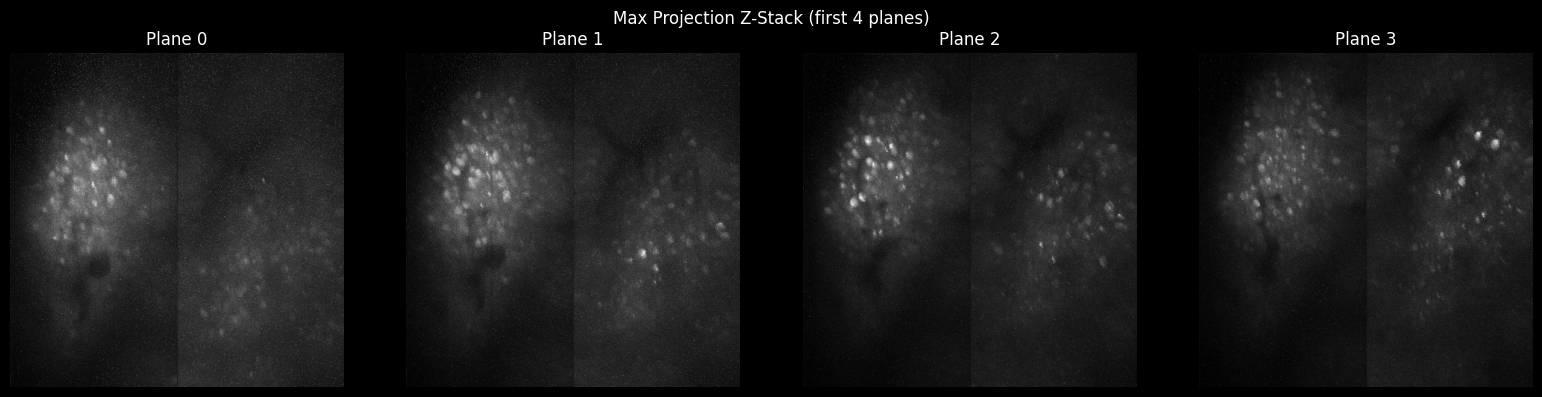

In [7]:
# Visualize the max projection
fig, axes = plt.subplots(1, min(4, n_planes), figsize=(16, 4))
if n_planes == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    if i < n_planes:
        ax.imshow(max_proj_3d[i], cmap='gray')
        ax.set_title(f'Plane {i}')
        ax.axis('off')

plt.suptitle('Max Projection Z-Stack (first 4 planes)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "max_proj_preview.png", dpi=150)
plt.show()

## Initialize Cellpose Model

In [8]:
use_gpu = core.use_gpu()
print(f"Using GPU: {use_gpu}")

model = models.CellposeModel(gpu=use_gpu)
print("Model loaded")

2025-12-03 14:17:54,329 [INFO] ** TORCH CUDA version installed and working. **
Using GPU: True
2025-12-03 14:17:54,329 [INFO] ** TORCH CUDA version installed and working. **
2025-12-03 14:17:54,329 [INFO] >>>> using GPU (CUDA)
2025-12-03 14:17:55,526 [INFO] >>>> loading model C:\Users\RBO\.cellpose\models\cpsam
Model loaded


## Method 1: True 3D Segmentation

Cellpose runs on all three orthogonal views (XY, ZY, ZX) and combines the results.

**Note**: This can be slow for anisotropic data where Z << X,Y because it processes 448 planes of size (14, 448) for the ZY view.

In [9]:
masks_3d_path = OUTPUT_DIR / "masks_3d_true.tif"
timing_3d = {}

if masks_3d_path.exists() and not FORCE:
    print(f"Loading existing 3D masks from {masks_3d_path}")
    masks_3d = tifffile.imread(masks_3d_path)
    timing_3d["loaded_from_cache"] = True
else:
    print("Running TRUE 3D segmentation...")
    print(f"This processes {n_planes} YX planes, {Ly} ZY planes, and {Lx} ZX planes")
    if ANISOTROPY is not None:
        print(f"Using anisotropy={ANISOTROPY}")
    else:
        print("Anisotropy=None (treating as isotropic)")

    t0 = time.perf_counter()
    masks_3d, flows_3d, styles_3d = model.eval(
        max_proj_3d,
        batch_size=32,
        flow_threshold=FLOW_THRESHOLD,
        cellprob_threshold=CELLPROB_THRESHOLD,
        do_3D=True,
        z_axis=0,
        anisotropy=ANISOTROPY,  # Use configured anisotropy (physical Z/XY ratio)
    )
    timing_3d["seconds"] = time.perf_counter() - t0

    tifffile.imwrite(masks_3d_path, masks_3d.astype(np.uint16))
    print(f"Saved to {masks_3d_path}")

n_cells_3d = int(masks_3d.max())
print(f"\nTrue 3D: {n_cells_3d} cells detected")
if "seconds" in timing_3d:
    print(f"Time: {timing_3d['seconds']:.2f}s")

Running TRUE 3D segmentation...
This processes 14 YX planes, 448 ZY planes, and 448 ZX planes
Anisotropy=None (treating as isotropic)
2025-12-03 14:17:55,975 [INFO] running YX: 14 planes of size (448, 448)
2025-12-03 14:18:00,941 [INFO] 100%|##########| 5/5 [00:04<00:00,  1.01it/s]
2025-12-03 14:18:00,966 [INFO] running ZY: 448 planes of size (14, 448)
2025-12-03 14:18:51,885 [INFO] 100%|##########| 45/45 [00:50<00:00,  1.13s/it]
2025-12-03 14:18:51,924 [INFO] running ZX: 448 planes of size (14, 448)
2025-12-03 14:19:43,747 [INFO] 100%|##########| 45/45 [00:51<00:00,  1.15s/it]
2025-12-03 14:19:43,819 [INFO] network run in 107.84s
2025-12-03 14:19:44,295 [INFO] masks created in 0.28s
Saved to D:\raw_scanimage_tiffs\cellpose_comparison\masks_3d_true.tif

True 3D: 269 cells detected
Time: 108.50s


## Method 2: Planar-Stitched Segmentation

Cellpose runs 2D on each Z-slice independently, then stitches masks across Z based on IoU overlap.

In [10]:
masks_stitched_path = OUTPUT_DIR / "masks_3d_stitched.tif"
timing_stitched = {}

if masks_stitched_path.exists() and not FORCE:
    print(f"Loading existing stitched masks from {masks_stitched_path}")
    masks_stitched = tifffile.imread(masks_stitched_path)
    timing_stitched["loaded_from_cache"] = True
else:
    print("Running PLANAR-STITCHED segmentation...")
    print(f"This processes {n_planes} planes independently, then stitches")

    t0 = time.perf_counter()
    masks_stitched, flows_stitched, styles_stitched = model.eval(
        max_proj_3d,
        batch_size=32,
        flow_threshold=FLOW_THRESHOLD,
        cellprob_threshold=CELLPROB_THRESHOLD,
        do_3D=False,  # Run 2D on each plane
        stitch_threshold=STITCH_THRESHOLD,  # Stitch across Z
        z_axis=0,
    )
    timing_stitched["seconds"] = time.perf_counter() - t0

    tifffile.imwrite(masks_stitched_path, masks_stitched.astype(np.uint16))
    print(f"Saved to {masks_stitched_path}")

n_cells_stitched = int(masks_stitched.max())
print(f"\nPlanar-Stitched: {n_cells_stitched} cells detected")
if "seconds" in timing_stitched:
    print(f"Time: {timing_stitched['seconds']:.2f}s")

Running PLANAR-STITCHED segmentation...
This processes 14 planes independently, then stitches
2025-12-03 14:19:49,420 [INFO] 100%|##########| 5/5 [00:04<00:00,  1.01it/s]
2025-12-03 14:19:49,424 [INFO] network run in 4.94s
2025-12-03 14:19:50,977 [INFO] 100%|##########| 14/14 [00:01<00:00,  9.29it/s]
2025-12-03 14:19:50,977 [INFO] stitching 14 planes using stitch_threshold=0.500 to make 3D masks


100%|██████████| 13/13 [00:00<00:00, 187.84it/s]

2025-12-03 14:19:51,075 [INFO] masks created in 1.61s


Saved to D:\raw_scanimage_tiffs\cellpose_comparison\masks_3d_stitched.tif

Planar-Stitched: 1234 cells detected
Time: 6.79s


## Comparison Results

In [11]:
# Summary statistics
print("=" * 50)
print("COMPARISON SUMMARY")
print("=" * 50)
print(f"Volume shape: {max_proj_3d.shape} (Z, Y, X)")
print(f"")
print(f"True 3D:        {n_cells_3d:4d} cells", end="")
if "seconds" in timing_3d:
    print(f"  ({timing_3d['seconds']:.1f}s)")
else:
    print(" (cached)")

print(f"Planar-Stitched: {n_cells_stitched:4d} cells", end="")
if "seconds" in timing_stitched:
    print(f"  ({timing_stitched['seconds']:.1f}s)")
else:
    print(" (cached)")

print(f"")
print(f"Difference: {n_cells_stitched - n_cells_3d:+d} cells ({100*(n_cells_stitched - n_cells_3d)/max(n_cells_3d, 1):+.1f}%)")

COMPARISON SUMMARY
Volume shape: (14, 448, 448) (Z, Y, X)

True 3D:         269 cells  (108.5s)
Planar-Stitched: 1234 cells  (6.8s)

Difference: +965 cells (+358.7%)


## Visual Comparison: Side-by-Side Masks

In [12]:
def mask_overlay(img, mask, alpha=0.5):
    """Create RGB overlay of mask on grayscale image."""
    from cellpose.plot import mask_rgb

    # Normalize image
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Create RGB from grayscale
    rgb = np.stack([img_norm, img_norm, img_norm], axis=-1)

    if mask.max() > 0:
        # Get colored masks
        mask_colors = mask_rgb(mask)

        # Blend
        mask_pixels = mask > 0
        rgb[mask_pixels] = (1 - alpha) * rgb[mask_pixels] + alpha * mask_colors[mask_pixels]

    return np.clip(rgb, 0, 1)

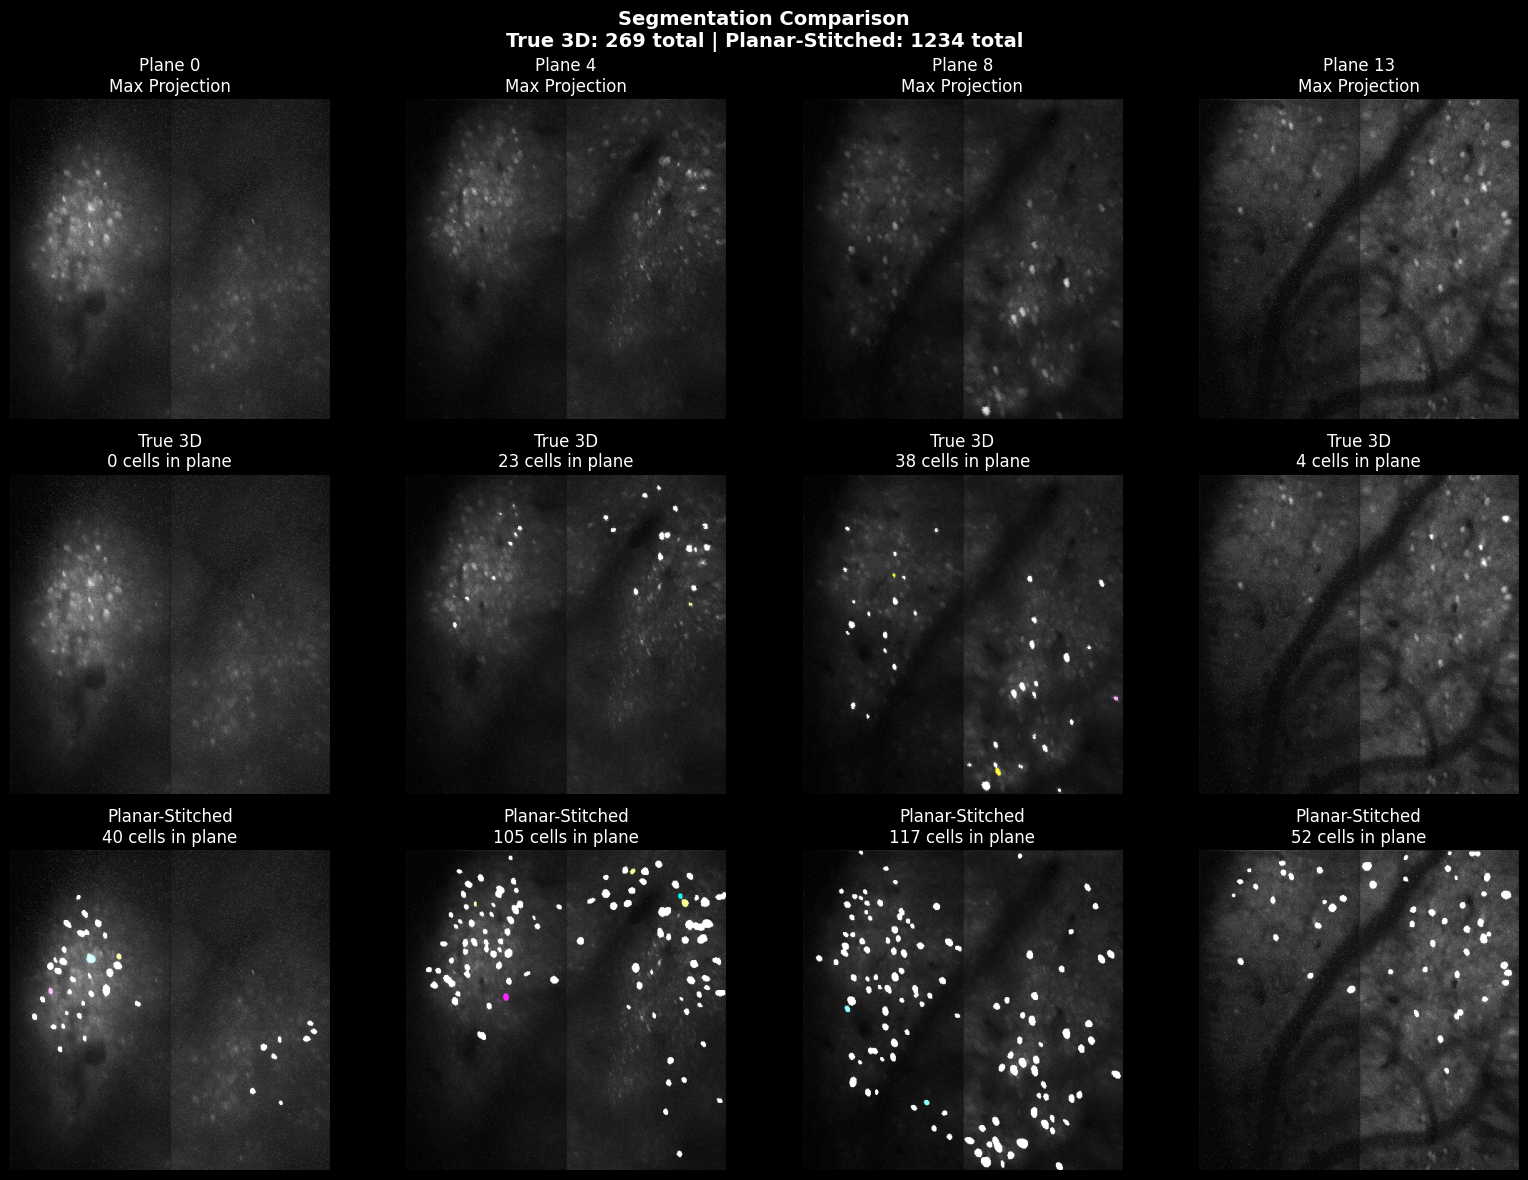

In [13]:
# Plot side-by-side comparison for multiple planes
n_show = min(4, n_planes)
plane_indices = np.linspace(0, n_planes - 1, n_show, dtype=int)

fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 12))
if n_show == 1:
    axes = axes[:, np.newaxis]

for col, plane_idx in enumerate(plane_indices):
    img = max_proj_3d[plane_idx]
    mask_3d_plane = masks_3d[plane_idx] if masks_3d.ndim == 3 else masks_3d
    mask_st_plane = masks_stitched[plane_idx] if masks_stitched.ndim == 3 else masks_stitched

    # Row 0: Original image
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(f'Plane {plane_idx}\nMax Projection')
    axes[0, col].axis('off')

    # Row 1: True 3D masks
    overlay_3d = mask_overlay(img, mask_3d_plane)
    axes[1, col].imshow(overlay_3d)
    n_cells_plane_3d = len(np.unique(mask_3d_plane)) - 1
    axes[1, col].set_title(f'True 3D\n{n_cells_plane_3d} cells in plane')
    axes[1, col].axis('off')

    # Row 2: Planar-stitched masks
    overlay_st = mask_overlay(img, mask_st_plane)
    axes[2, col].imshow(overlay_st)
    n_cells_plane_st = len(np.unique(mask_st_plane)) - 1
    axes[2, col].set_title(f'Planar-Stitched\n{n_cells_plane_st} cells in plane')
    axes[2, col].axis('off')

plt.suptitle(f'Segmentation Comparison\nTrue 3D: {n_cells_3d} total | Planar-Stitched: {n_cells_stitched} total',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_masks.png", dpi=200, bbox_inches='tight')
plt.show()

## Cell Size Distribution Comparison

In [14]:
def get_cell_sizes(masks):
    """Get pixel count for each cell."""
    labels = np.unique(masks)
    labels = labels[labels > 0]  # Exclude background
    sizes = [np.sum(masks == label) for label in labels]
    return np.array(sizes)

sizes_3d = get_cell_sizes(masks_3d)
sizes_stitched = get_cell_sizes(masks_stitched)

print(f"True 3D cell sizes: min={sizes_3d.min()}, median={np.median(sizes_3d):.0f}, max={sizes_3d.max()}")
print(f"Stitched cell sizes: min={sizes_stitched.min()}, median={np.median(sizes_stitched):.0f}, max={sizes_stitched.max()}")

True 3D cell sizes: min=15, median=32, max=122
Stitched cell sizes: min=15, median=67, max=249


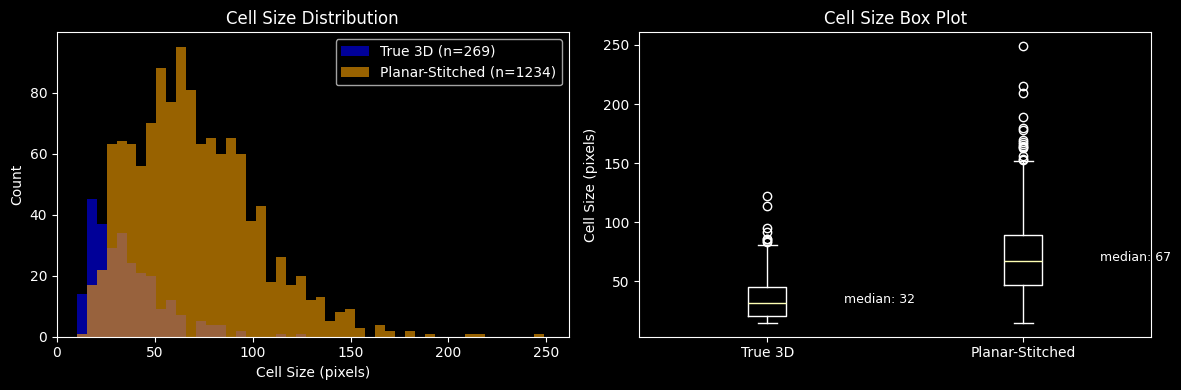

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram comparison
ax = axes[0]
bins = np.linspace(0, max(sizes_3d.max(), sizes_stitched.max()), 50)
ax.hist(sizes_3d, bins=bins, alpha=0.6, label=f'True 3D (n={len(sizes_3d)})', color='blue')
ax.hist(sizes_stitched, bins=bins, alpha=0.6, label=f'Planar-Stitched (n={len(sizes_stitched)})', color='orange')
ax.set_xlabel('Cell Size (pixels)')
ax.set_ylabel('Count')
ax.set_title('Cell Size Distribution')
ax.legend()
ax.set_xlim(0, None)

# Box plot comparison
ax = axes[1]
bp = ax.boxplot([sizes_3d, sizes_stitched], labels=['True 3D', 'Planar-Stitched'])
ax.set_ylabel('Cell Size (pixels)')
ax.set_title('Cell Size Box Plot')

# Add median annotations
for i, sizes in enumerate([sizes_3d, sizes_stitched], 1):
    ax.annotate(f'median: {np.median(sizes):.0f}',
                xy=(i, np.median(sizes)),
                xytext=(i + 0.3, np.median(sizes)),
                fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_cell_sizes.png", dpi=150)
plt.show()

## Per-Plane Cell Count Comparison

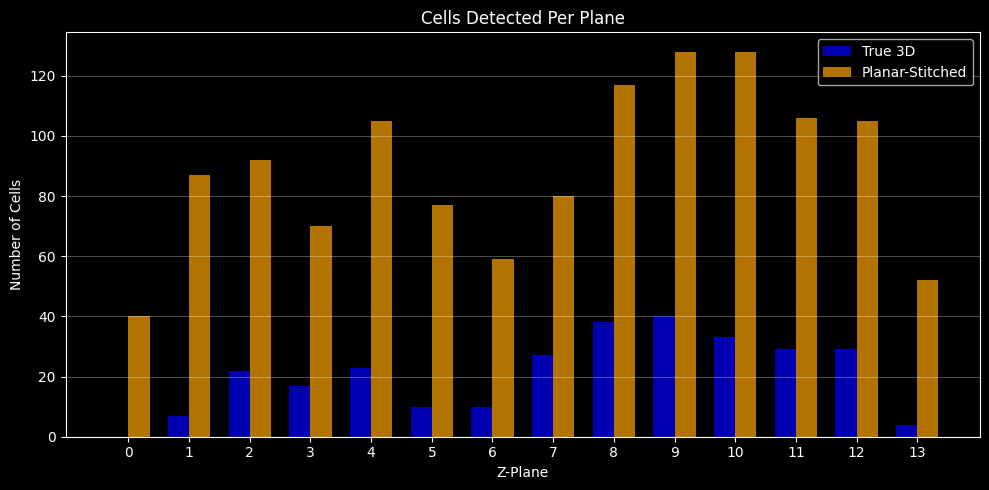

In [16]:
def cells_per_plane(masks):
    """Count unique cells in each Z-plane."""
    if masks.ndim == 2:
        return [len(np.unique(masks)) - 1]
    counts = []
    for z in range(masks.shape[0]):
        n_cells = len(np.unique(masks[z])) - 1  # -1 for background
        counts.append(n_cells)
    return counts

counts_3d = cells_per_plane(masks_3d)
counts_stitched = cells_per_plane(masks_stitched)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(counts_3d))
width = 0.35

bars1 = ax.bar(x - width/2, counts_3d, width, label='True 3D', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, counts_stitched, width, label='Planar-Stitched', color='orange', alpha=0.7)

ax.set_xlabel('Z-Plane')
ax.set_ylabel('Number of Cells')
ax.set_title('Cells Detected Per Plane')
ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_cells_per_plane.png", dpi=150)
plt.show()

## Mask Overlap Analysis (IoU)

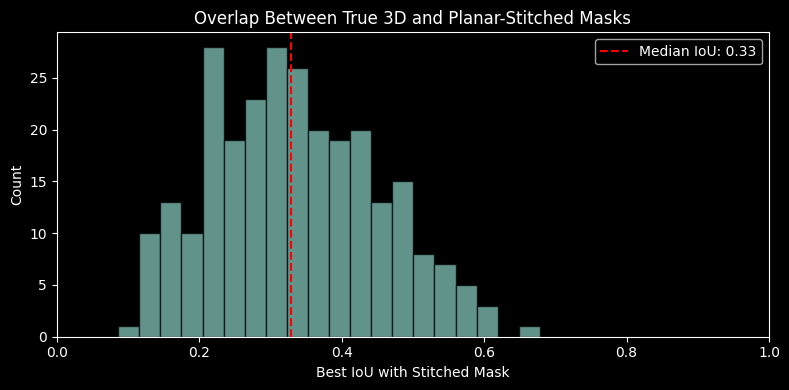


IoU Statistics:
  Mean IoU: 0.334
  Median IoU: 0.329
  Masks with IoU > 0.5: 24 / 269 (8.9%)


In [17]:
from cellpose.metrics import mask_ious

# Compute IoU between matching masks from both methods
# This tells us how similar the segmentations are

if masks_3d.shape == masks_stitched.shape:
    # Flatten for comparison
    ious, mapping = mask_ious(masks_3d.flatten().reshape(masks_3d.shape),
                               masks_stitched.flatten().reshape(masks_stitched.shape))

    if len(ious) > 0:
        # Get best IoU for each mask in 3D result
        best_ious = ious.max(axis=1) if ious.ndim > 1 else ious

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(best_ious, bins=20, edgecolor='black', alpha=0.7)
        ax.axvline(np.median(best_ious), color='red', linestyle='--',
                   label=f'Median IoU: {np.median(best_ious):.2f}')
        ax.set_xlabel('Best IoU with Stitched Mask')
        ax.set_ylabel('Count')
        ax.set_title('Overlap Between True 3D and Planar-Stitched Masks')
        ax.legend()
        ax.set_xlim(0, 1)

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "comparison_iou.png", dpi=150)
        plt.show()

        print(f"\nIoU Statistics:")
        print(f"  Mean IoU: {np.mean(best_ious):.3f}")
        print(f"  Median IoU: {np.median(best_ious):.3f}")
        print(f"  Masks with IoU > 0.5: {np.sum(best_ious > 0.5)} / {len(best_ious)} ({100*np.mean(best_ious > 0.5):.1f}%)")
    else:
        print("No overlapping masks found for IoU comparison")
else:
    print(f"Mask shapes differ: {masks_3d.shape} vs {masks_stitched.shape}")

## Summary Figure

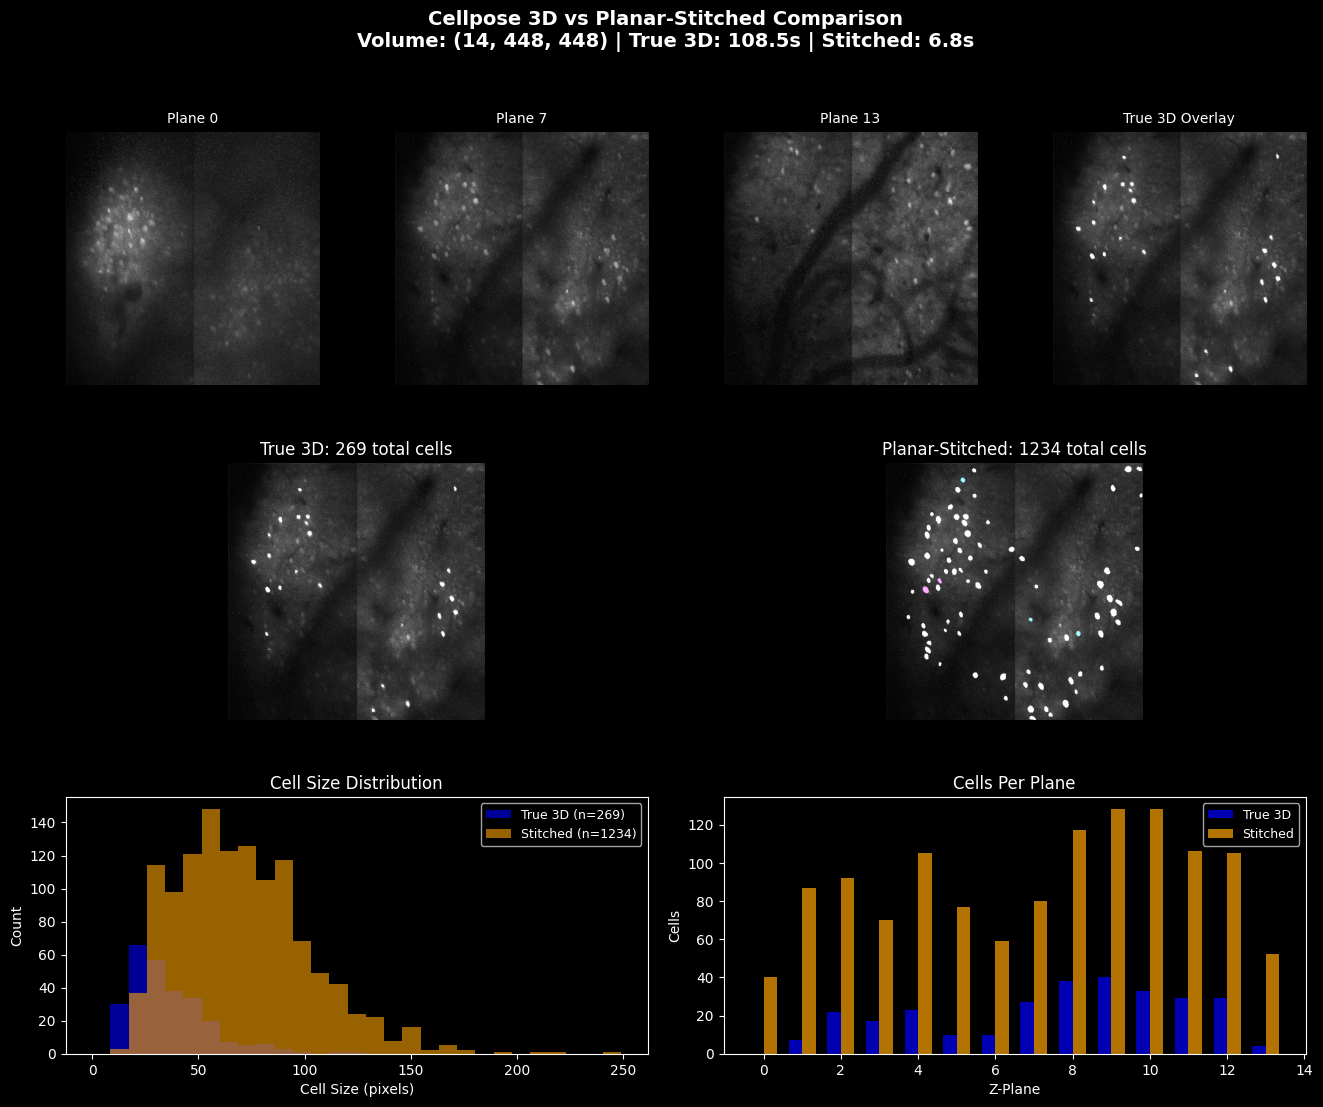


All results saved to: D:\raw_scanimage_tiffs\cellpose_comparison


In [18]:
# Create a comprehensive summary figure
fig = plt.figure(figsize=(16, 12))

# Use gridspec for flexible layout
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Sample planes comparison (4 planes)
mid_plane = n_planes // 2
for col, plane_idx in enumerate([0, mid_plane, n_planes - 1, mid_plane]):
    ax = fig.add_subplot(gs[0, col])
    img = max_proj_3d[min(plane_idx, n_planes - 1)]

    if col < 3:
        # Show raw image for first 3
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Plane {min(plane_idx, n_planes - 1)}', fontsize=10)
    else:
        # Show overlay comparison for last
        mask_3d_plane = masks_3d[mid_plane] if masks_3d.ndim == 3 else masks_3d
        overlay = mask_overlay(img, mask_3d_plane)
        ax.imshow(overlay)
        ax.set_title('True 3D Overlay', fontsize=10)
    ax.axis('off')

# Row 2: Mask comparison
ax1 = fig.add_subplot(gs[1, 0:2])
mid_img = max_proj_3d[mid_plane] if n_planes > 1 else max_proj_3d
mid_mask_3d = masks_3d[mid_plane] if masks_3d.ndim == 3 else masks_3d
ax1.imshow(mask_overlay(mid_img, mid_mask_3d))
ax1.set_title(f'True 3D: {n_cells_3d} total cells', fontsize=12)
ax1.axis('off')

ax2 = fig.add_subplot(gs[1, 2:4])
mid_mask_st = masks_stitched[mid_plane] if masks_stitched.ndim == 3 else masks_stitched
ax2.imshow(mask_overlay(mid_img, mid_mask_st))
ax2.set_title(f'Planar-Stitched: {n_cells_stitched} total cells', fontsize=12)
ax2.axis('off')

# Row 3: Statistics
ax3 = fig.add_subplot(gs[2, 0:2])
bins = np.linspace(0, max(sizes_3d.max(), sizes_stitched.max()), 30)
ax3.hist(sizes_3d, bins=bins, alpha=0.6, label=f'True 3D (n={len(sizes_3d)})', color='blue')
ax3.hist(sizes_stitched, bins=bins, alpha=0.6, label=f'Stitched (n={len(sizes_stitched)})', color='orange')
ax3.set_xlabel('Cell Size (pixels)')
ax3.set_ylabel('Count')
ax3.set_title('Cell Size Distribution')
ax3.legend(fontsize=9)

ax4 = fig.add_subplot(gs[2, 2:4])
x = np.arange(len(counts_3d))
width = 0.35
ax4.bar(x - width/2, counts_3d, width, label='True 3D', color='blue', alpha=0.7)
ax4.bar(x + width/2, counts_stitched, width, label='Stitched', color='orange', alpha=0.7)
ax4.set_xlabel('Z-Plane')
ax4.set_ylabel('Cells')
ax4.set_title('Cells Per Plane')
ax4.legend(fontsize=9)

# Title
time_str_3d = f"{timing_3d.get('seconds', 0):.1f}s" if 'seconds' in timing_3d else "cached"
time_str_st = f"{timing_stitched.get('seconds', 0):.1f}s" if 'seconds' in timing_stitched else "cached"
fig.suptitle(f'Cellpose 3D vs Planar-Stitched Comparison\n'
             f'Volume: {max_proj_3d.shape} | True 3D: {time_str_3d} | Stitched: {time_str_st}',
             fontsize=14, fontweight='bold')

plt.savefig(OUTPUT_DIR / "comparison_summary.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"\nAll results saved to: {OUTPUT_DIR}")

## Save Timing Log

In [19]:
# Save comparison results
results = {
    "input_path": str(INPUT_PATH),
    "volume_shape": list(max_proj_3d.shape),
    "parameters": {
        "flow_threshold": FLOW_THRESHOLD,
        "cellprob_threshold": CELLPROB_THRESHOLD,
        "stitch_threshold": STITCH_THRESHOLD,
    },
    "true_3d": {
        "n_cells": n_cells_3d,
        "timing_seconds": timing_3d.get("seconds"),
        "median_cell_size": float(np.median(sizes_3d)),
    },
    "planar_stitched": {
        "n_cells": n_cells_stitched,
        "timing_seconds": timing_stitched.get("seconds"),
        "median_cell_size": float(np.median(sizes_stitched)),
    },
    "comparison": {
        "cell_count_difference": n_cells_stitched - n_cells_3d,
        "cell_count_difference_percent": 100 * (n_cells_stitched - n_cells_3d) / max(n_cells_3d, 1),
    }
}

with open(OUTPUT_DIR / "comparison_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Results saved to comparison_results.json")
print(json.dumps(results, indent=2))

Results saved to comparison_results.json
{
  "input_path": "D:\\raw_scanimage_tiffs",
  "volume_shape": [
    14,
    448,
    448
  ],
  "parameters": {
    "flow_threshold": 0.4,
    "cellprob_threshold": 0.0,
    "stitch_threshold": 0.5
  },
  "true_3d": {
    "n_cells": 269,
    "timing_seconds": 108.5004276000036,
    "median_cell_size": 32.0
  },
  "planar_stitched": {
    "n_cells": 1234,
    "timing_seconds": 6.788196600005904,
    "median_cell_size": 67.0
  },
  "comparison": {
    "cell_count_difference": 965,
    "cell_count_difference_percent": 358.7360594795539
  }
}
